# M7 - Quality, Yield and Virtual Metrology

**Goal.** Add a lot-level quality and yield layer on top of the M2-M6 fab
simulator, then use it two ways: (a) a leakage-safe virtual-metrology model
that predicts a noisy quality signal from strictly upstream process
variables, and (b) a yield-aware what-if comparison that reports cycle time
AND yield risk side by side, CRN-paired the same way M4/M6 pair their
capacity and cost comparisons.

**Structure.**
1. Post-litho queue-time windows: a stylized photoresist-aging analogy that
   turns "how long did a lot wait after LITHO" into a risk signal.
2. Ground-truth yield model: a transparent, linear-additive latent defect
   probability, with a realized Binomial(25) defect count per lot.
3. Virtual metrology: a hand-built OLS model predicting the noisy metrology
   reading from upstream-only features, evaluated on a held-out future
   window (no leakage).
4. Chamber matching: a two-sample comparison of the two LITHO tools, with a
   false-positive guard on an offset-free log.
5. Yield-aware what-if: the same CRN-paired comparison machinery as M4/M6,
   now reporting cycle time and yield risk together for three scenarios.

**Honest scope.** Every number in this notebook comes from the synthetic fab
line (`src/generator`), where the yield coefficients are hand-set constants
chosen by the project owner, not fitted from any real fab. Ground truth is
known exactly because it was written down first (`QualityConfig`), so the
virtual-metrology model can be checked against it directly; that is a
capability real fabs do not have. The post-litho queue-time window borrows
the SHAPE of a real litho photoresist-aging constraint (wait too long after
coating, risk rises) without modeling resist chemistry or any physical
mechanism; it is a stylized analogy, not a physical model. Read every number
below as a ranking under these stated assumptions, not as a claim about any
real fabrication line.


In [1]:
get_ipython().run_line_magic('matplotlib', 'inline')
import copy
import sys
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
plt.rcParams.update({"figure.dpi": 110, "font.size": 10})

ROOT = Path("..")
for p in ["src", "src/generator", "src/bottleneck", "src/monitoring", "src/decision", "src/quality"]:
    sys.path.insert(0, str(ROOT / p))

from factory_generator import default_config, simulate
from queue_time import post_litho_queue_times, flag_violations, calibrate_window, DEFAULT_WINDOW_HOURS
from yield_model import QualityConfig, build_lot_quality, WAFERS_PER_LOT
from virtual_metrology import (
    build_features, time_split, fit_ols, predict,
    r2_vs_mean_baseline, risk_ranking_auc, fit_and_evaluate, FEATURE_COLUMNS,
)
from chamber_matching import compare_litho_tools, daily_mean_series, mismatch_verdict
from yield_whatif import (
    paired_yield_comparison, summarize_yield_comparison,
    demo_extra_litho_tool, demo_demand_increase, demo_chamber_offset,
)

FIG = ROOT / "reports" / "figures"; FIG.mkdir(parents=True, exist_ok=True)

cfg = default_config()
log, life, meta = simulate(cfg)
print(f"route: {cfg.route}")
print(f"lots simulated: {log['lot_id'].nunique()}, event rows: {len(log)}")


C:\Users\User\anaconda3\Lib\site-packages\pandas\core\arrays\masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


route: ['CLEAN', 'FURNACE', 'DEPO', 'LITHO', 'ETCH', 'LITHO', 'IMPLANT', 'METRO']
lots simulated: 1429, event rows: 11432


## Step 1 - Post-litho queue-time windows

Real litho cells enforce a hard queue-time (Q-time) limit between coating a
wafer and exposing/developing it: once photoresist is applied, airborne
contamination and resist relaxation degrade the pattern if the wafer waits
too long before the next step. This module (`src/quality/queue_time.py`)
borrows the SHAPE of that idea, nothing more: for each of the two LITHO
visits in the locked route (`CLEAN FURNACE DEPO LITHO ETCH LITHO IMPLANT
METRO`), the "gap" is the wait between finishing that LITHO visit and
starting the immediately following step. A violation is flagged when
`gap > W` for a fixed window `W`.

**Calibration provenance.** `W` was calibrated once against the
default-seed baseline log (seed 42, no anomalies, no tool offsets) as the
90th percentile of the pooled (both-visit) gap distribution, then hand-copied
into `DEFAULT_WINDOW_HOURS` as a fixed constant so violation flags stay
comparable across every scenario that reuses it. Re-running the calibration
call below reproduces the same window bit-for-bit because the DES is fully
seeded.


In [2]:
tidy_gaps = post_litho_queue_times(log, cfg.route)
W_recalibrated, viol_rate_recalibrated = calibrate_window(log, cfg.route, quantile=0.90)
viol = flag_violations(log, cfg.route)
baseline_violation_rate = float(viol["violation"].mean())

print(f"DEFAULT_WINDOW_HOURS (fixed)      : {DEFAULT_WINDOW_HOURS:.6f} h")
print(f"recalibrated W on this run        : {W_recalibrated:.6f} h (matches fixed constant: "
      f"{abs(W_recalibrated - DEFAULT_WINDOW_HOURS) < 1e-9})")
print(f"baseline violation rate           : {baseline_violation_rate:.4f} "
      f"({baseline_violation_rate*100:.1f}% of LITHO visits)")
print(f"pooled gap observations           : {len(tidy_gaps)}")


DEFAULT_WINDOW_HOURS (fixed)      : 0.410203 h
recalibrated W on this run        : 0.410203 h (matches fixed constant: True)
baseline violation rate           : 0.1001 (10.0% of LITHO visits)
pooled gap observations           : 2858


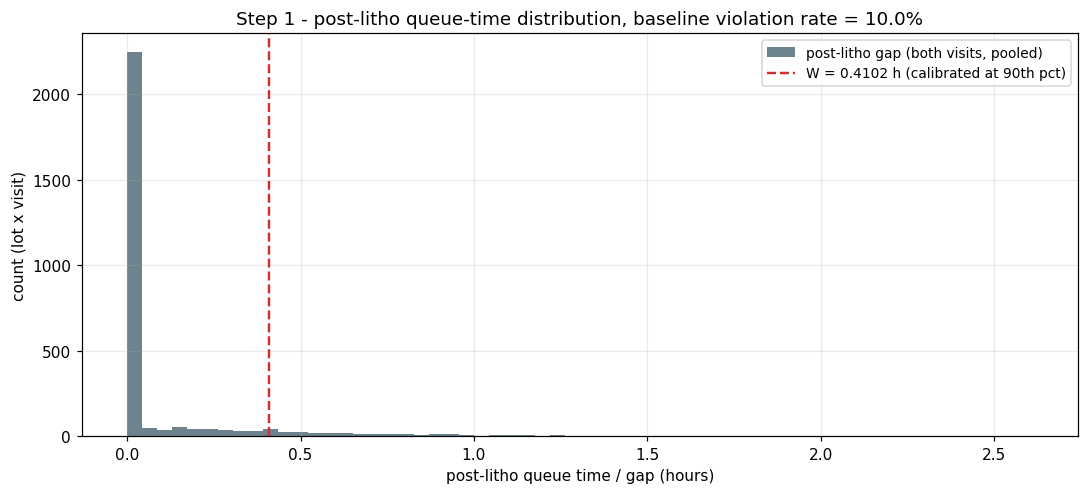

In [3]:
fig, ax = plt.subplots(figsize=(10, 4.6))
ax.hist(tidy_gaps["gap"], bins=60, color="#546E7A", alpha=0.85, label="post-litho gap (both visits, pooled)")
ax.axvline(DEFAULT_WINDOW_HOURS, color="#D32F2F", ls="--", lw=1.6,
           label=f"W = {DEFAULT_WINDOW_HOURS:.4f} h (calibrated at 90th pct)")
ax.set_xlabel("post-litho queue time / gap (hours)")
ax.set_ylabel("count (lot x visit)")
ax.set_title(f"Step 1 - post-litho queue-time distribution, baseline violation rate = "
             f"{baseline_violation_rate*100:.1f}%")
ax.legend(fontsize=9)
ax.grid(alpha=0.25)
fig.tight_layout()
fig.savefig(FIG / "m7_queue_time_window.png", bbox_inches="tight", dpi=150)
plt.show()


**Reading.** Most lots move to the next step quickly (a large mass at
gap approx 0), but a long right tail exists because of queueing at the
shared LITHO tools; the fixed window `W` sits at the 90th percentile of that
pooled distribution, so a little under 1 in 10 LITHO visits (about 10%) is
flagged as a queue-time violation on the untouched baseline line. This
violation flag is the risk signal that feeds the yield model in Step 2 and
is later re-measured under each what-if scenario in Step 5.


## Step 2 - Ground-truth yield model

`src/quality/yield_model.py` turns each lot's queue-time violation flags,
which LITHO tool served it, and its own ETCH process-time excess into a
per-wafer LATENT defect probability `p_latent`, using a plain SUM of
independent additive terms (clipped to [0, 0.95]):

```
p_latent = clip(p_base
                + a_viol1 * 1{first LITHO visit violated the window}
                + a_viol2 * 1{second LITHO visit violated the window}
                + a_chamber * 1{lot ran on the off-nominal LITHO tool}
                + a_pt_excess * standardized ETCH slow-side excess,
                0, 0.95)
```

**Why linear-additive, not logistic.** A logistic link (`p = sigmoid(...)`)
is the textbook choice for a probability model, but it turns each
coefficient into a multiplicative, curve-position-dependent statement about
log-odds. The interpretability rule for this project (CLAUDE.md: choose the
simplest technique that can be explained from first principles) asks for
coefficients that are directly readable as "probability points added by this
condition" everywhere in the interior of the clip range, which is exactly
what the linear-additive form gives. The clip to [0, 0.95] is the one place
linearity is deliberately broken, only at the extremes, to keep `p_latent` a
valid probability.

The REALIZED outcome for each 25-wafer lot is one Binomial(25, p_latent)
draw from a dedicated, seeded random generator kept separate from the DES's
own draws, so scoring a log for yield never disturbs the DES's own
reproducibility guarantees.


In [4]:
qcfg = QualityConfig()
print("QualityConfig (documented coefficients):")
for field_name in ["p_base", "a_viol1", "a_viol2", "a_chamber", "a_pt_excess", "seed"]:
    print(f"  {field_name:<14} = {getattr(qcfg, field_name)}")

lot_quality = build_lot_quality(log, cfg.route, qcfg)
lot_quality.head()


QualityConfig (documented coefficients):
  p_base         = 0.02
  a_viol1        = 0.06
  a_viol2        = 0.08
  a_chamber      = 0.03
  a_pt_excess    = 0.04
  seed           = 42


,lot_id,viol_litho1,viol_litho2,litho1_tool,litho2_tool,pt_excess_etch,p_latent,defects,lot_yield,metrology_reading
0,0,False,False,LITHO-1,LITHO-1,1.577426,0.083097,3,0.88,0.073939
1,1,False,False,LITHO-1,LITHO-1,0.000000,0.020000,0,1.00,0.013281
2,2,False,False,LITHO-2,LITHO-2,0.000000,0.020000,1,0.96,0.034774
3,3,False,False,LITHO-1,LITHO-2,0.000000,0.020000,1,0.96,0.014574
4,4,False,False,LITHO-2,LITHO-1,0.000000,0.020000,0,1.00,0.024622


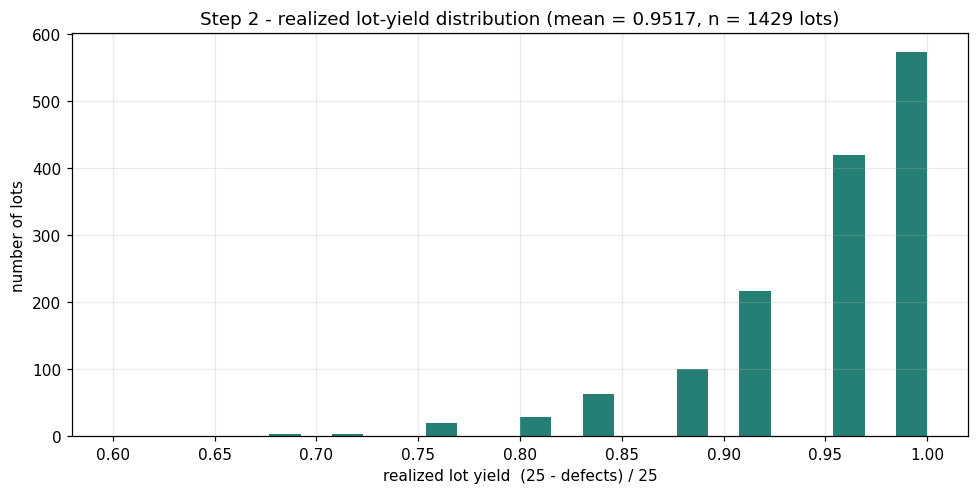

In [5]:
fig, ax = plt.subplots(figsize=(9, 4.6))
ax.hist(lot_quality["lot_yield"], bins=26, color="#00695C", alpha=0.85)
ax.set_xlabel("realized lot yield  (25 - defects) / 25")
ax.set_ylabel("number of lots")
ax.set_title(f"Step 2 - realized lot-yield distribution "
             f"(mean = {lot_quality['lot_yield'].mean():.4f}, n = {len(lot_quality)} lots)")
ax.grid(alpha=0.25)
fig.tight_layout()
fig.savefig(FIG / "m7_lot_yield_distribution.png", bbox_inches="tight", dpi=150)
plt.show()


**Monotonicity check.** Because the additive terms are deterministic given
the violation flags, lots that breached either LITHO queue-time window
should show a strictly higher mean latent defect probability, and (as a
directional check on the realized, noisy outcome) a higher realized defect
rate, than clean lots.


In [6]:
violating = lot_quality["viol_litho1"] | lot_quality["viol_litho2"]
mono = pd.DataFrame({
    "group": ["violating (either LITHO visit)", "clean (no violation)"],
    "n_lots": [int(violating.sum()), int((~violating).sum())],
    "mean_p_latent": [lot_quality.loc[violating, "p_latent"].mean(),
                       lot_quality.loc[~violating, "p_latent"].mean()],
    "mean_realized_defect_rate": [
        (lot_quality.loc[violating, "defects"] / WAFERS_PER_LOT).mean(),
        (lot_quality.loc[~violating, "defects"] / WAFERS_PER_LOT).mean(),
    ],
    "mean_lot_yield": [lot_quality.loc[violating, "lot_yield"].mean(),
                        lot_quality.loc[~violating, "lot_yield"].mean()],
})
mono.round(4)


,group,n_lots,mean_p_latent,mean_realized_defect_rate,mean_lot_yield
0,violating (either LITHO visit),260,0.1099,0.1103,0.8897
1,clean (no violation),1169,0.0343,0.0345,0.9655


Violating lots carry both a higher latent risk and a higher realized defect
rate than clean lots, exactly as the additive design intends: a queue-time
violation is not a cosmetic label, it moves the lot's own yield outcome.


## Step 3 - Virtual metrology

`src/quality/virtual_metrology.py` predicts `metrology_reading` (Stage B's
noisy stand-in for a real virtual-metrology sensor) from a leakage-safe
feature set built only from information available before or at the METRO
step: both LITHO visits' queue-time gaps and violation flags, both LITHO
visits' process durations, ETCH process duration and its standardized
excess, and which physical tool ran each LITHO visit. `p_latent`, `defects`,
and `lot_yield` are labels derived from the same risk factors and are never
used as features, since they would leak the answer back into a predictor of
a noisy version of itself.

**Leakage-safe split.** Lots are sorted by their own completion time and
split 70/30 (train = first 70%, test = last 30%), not a random split. A
random split would leak information across the boundary through shared tool
occupancy and queue congestion between nearby-in-time lots; a held-out
FUTURE window matches how a virtual-metrology model would actually be
deployed, fit on history, score lots not yet metrology-inspected.

The model itself is a hand-built ordinary-least-squares regression
(`numpy.linalg.lstsq`), no `sklearn`, consistent with the project's
interpretable-methods rule.


In [7]:
vm_result = fit_and_evaluate(log, cfg.route, lot_quality, DEFAULT_WINDOW_HOURS)
print(f"train lots: {vm_result.metrics['n_train']}   test lots: {vm_result.metrics['n_test']}")
print(f"test R^2 (vs train-mean baseline) : {vm_result.metrics['test_r2']:.4f}")
print(f"risk-ranking AUC (defects > 0)    : {vm_result.metrics['auc']:.4f}")
vm_result.coef_table


train lots: 1000   test lots: 429
test R^2 (vs train-mean baseline) : 0.9315
risk-ranking AUC (defects > 0)    : 0.7278


,feature,coefficient,interpretation
0,intercept,0.016464,baseline predicted metrology reading with all ...
1,gap1,0.005994,each extra hour of post-litho-visit-1 queue wa...
2,gap2,-0.000748,each extra hour of post-litho-visit-2 queue wa...
3,viol_litho1,0.056198,breaching the visit-1 queue-time window raises...
4,viol_litho2,0.081929,breaching the visit-2 queue-time window raises...
5,litho1_pt,0.000723,each extra hour of LITHO visit-1 processing ti...
6,litho2_pt,0.000477,each extra hour of LITHO visit-2 processing ti...
7,etch_pt,0.001901,each extra hour of ETCH processing time shifts...
8,pt_excess_etch,0.038375,each standardized unit of slow-side ETCH exces...
9,litho1_is_toolB,0.000262,running LITHO visit 1 on the later-labeled too...


**Plain-English reading of the coefficient table.** The two violation-flag
coefficients (`viol_litho1`, `viol_litho2`) are positive, which is the OLS
recovering the exact risk drivers `yield_model.py` injected: breaching
either post-litho queue-time window raises the predicted metrology reading.
The queue-time gap coefficients (`gap1`, `gap2`) point the same direction as
a continuous version of the same signal. Tool-identity and process-time
coefficients pick up the remaining, smaller effects (chamber and ETCH
excess) built into the same additive formula.

**Why R^2 is high.** The test R^2 above is high because the generative
ground truth is a simple, known, linear-additive formula and the fitted
model is the correctly specified functional form for it. That is a property
of this synthetic exercise, not a property of virtual metrology on a real
fab. The point of this step is the leakage-safe measurement methodology
(time-based split, upstream-only features, a train-mean baseline
comparator, a rank-based AUC for risk triage), not the score itself; on a
real line with unknown, non-linear ground truth and measurement noise, an
R^2 this high would not be expected.


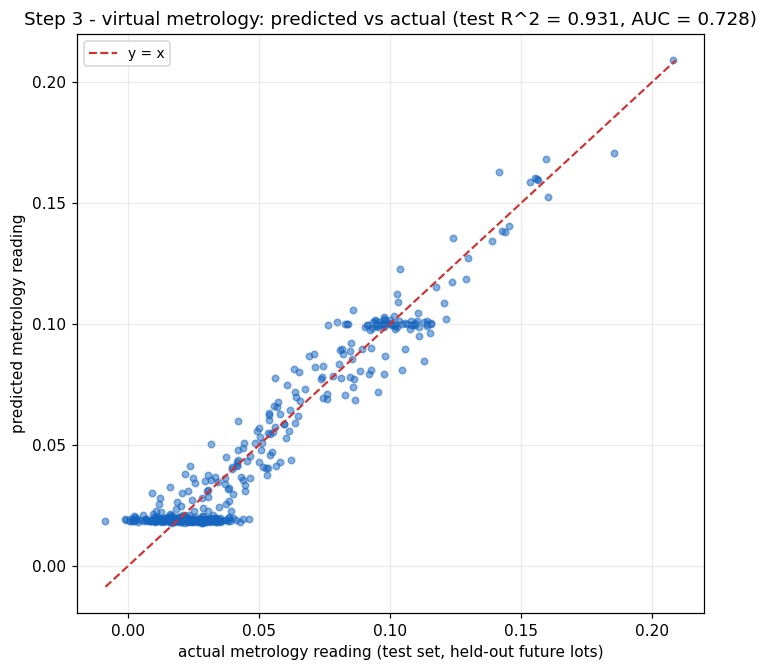

In [8]:
fig, ax = plt.subplots(figsize=(6.6, 6.2))
ax.scatter(vm_result.y_test_true, vm_result.y_test_pred, s=18, alpha=0.5, color="#1565C0")
lims = [min(vm_result.y_test_true.min(), vm_result.y_test_pred.min()),
        max(vm_result.y_test_true.max(), vm_result.y_test_pred.max())]
ax.plot(lims, lims, color="#D32F2F", ls="--", lw=1.4, label="y = x")
ax.set_xlabel("actual metrology reading (test set, held-out future lots)")
ax.set_ylabel("predicted metrology reading")
ax.set_title(f"Step 3 - virtual metrology: predicted vs actual "
             f"(test R^2 = {vm_result.metrics['test_r2']:.3f}, AUC = {vm_result.metrics['auc']:.3f})")
ax.legend(fontsize=9)
ax.grid(alpha=0.25)
fig.tight_layout()
fig.savefig(FIG / "m7_vm_pred_vs_actual.png", bbox_inches="tight", dpi=150)
plt.show()


## Step 4 - Chamber matching: LITHO-1 vs LITHO-2

A classic fab question: are two nominally-identical process chambers
actually behaving the same, or has one drifted? To demonstrate the method,
we generate a second log where LITHO's two tools carry different processing
-time multipliers (`tool_offsets = (1.05, 0.95)`, i.e. LITHO-1 stylized as
5% slower, LITHO-2 as 5% faster than nominal) and compare them with
`scipy` two-sample tests (`src/quality/chamber_matching.py`): Welch's
t-test and Mann-Whitney U on both LITHO processing durations and downstream
metrology readings.


In [9]:
cfg_offset = copy.deepcopy(default_config())
cfg_offset.stations["LITHO"].tool_offsets = (1.05, 0.95)  # LITHO-1 slower
log_offset, life_offset, _ = simulate(cfg_offset)

qcfg_offset = QualityConfig(off_nominal_tool_label="LITHO-1")
lot_quality_offset = build_lot_quality(log_offset, cfg_offset.route, qcfg_offset)

chamber_results = compare_litho_tools(log_offset, cfg_offset.route, lot_quality_offset)
chamber_verdict = mismatch_verdict(chamber_results, alpha=0.01)

rows = []
for name, r in chamber_results.items():
    rows.append({
        "metric": name,
        "mean_LITHO-1": r.mean_tool1,
        "mean_LITHO-2": r.mean_tool2,
        "t_pvalue": r.t_pvalue,
        "mannwhitney_pvalue": r.u_pvalue,
        "cohens_d": r.cohens_d,
        "verdict (alpha=0.01)": chamber_verdict[name],
    })
chamber_table = pd.DataFrame(rows)
chamber_table


,metric,mean_LITHO-1,mean_LITHO-2,t_pvalue,mannwhitney_pvalue,cohens_d,verdict (alpha=0.01)
0,processing_duration,0.880865,0.805834,2.387922e-06,6.029644e-06,0.176884,detected
1,metrology_reading,0.076524,0.050315,1.635509e-15,4.385336e-23,0.622868,detected


**False-positive guard.** The same comparison run on the offset-free
baseline log (no `tool_offsets`, both tools drawn from the identical
distribution) must stay silent, "not detected", on both metrics; otherwise
the test would be flagging noise rather than a real injected mismatch.


In [10]:
lot_quality_free = build_lot_quality(log, cfg.route, QualityConfig())
chamber_results_free = compare_litho_tools(log, cfg.route, lot_quality_free)
chamber_verdict_free = mismatch_verdict(chamber_results_free, alpha=0.01)
print("offset-free log verdicts (must be 'not detected' on both):")
for name, v in chamber_verdict_free.items():
    print(f"  {name:<20} : {v}")


offset-free log verdicts (must be 'not detected' on both):
  processing_duration  : not detected
  metrology_reading    : not detected


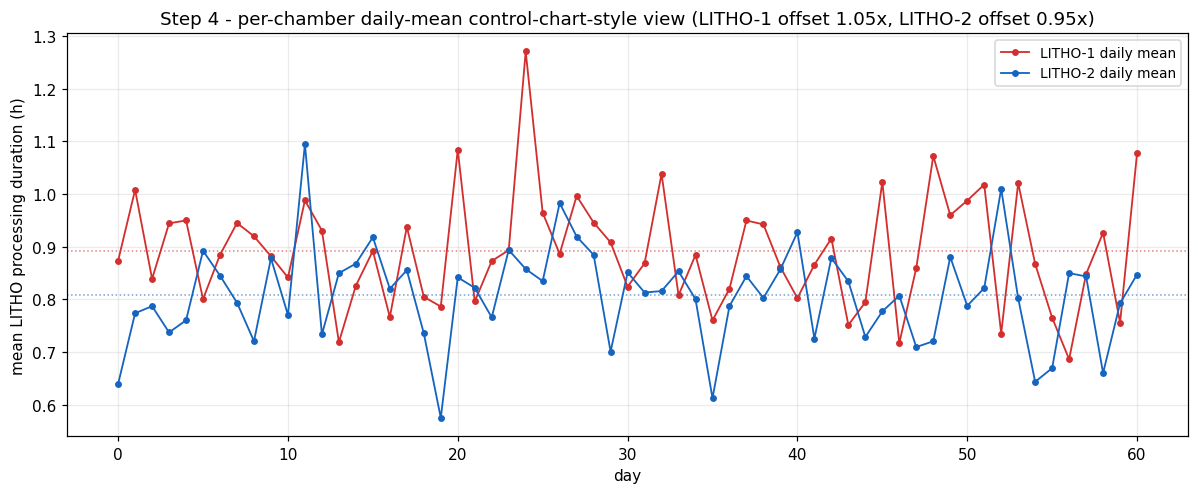

In [11]:
daily = daily_mean_series(log_offset, cfg_offset.route)
fig, ax = plt.subplots(figsize=(11, 4.6))
colors = {"LITHO-1": "#D32F2F", "LITHO-2": "#1565C0"}
for tool, grp in daily.groupby("tool_id"):
    ax.plot(grp["day"], grp["mean_duration"], marker="o", ms=3.5, lw=1.2,
            color=colors[tool], label=f"{tool} daily mean")
    center = grp["mean_duration"].mean()
    ax.axhline(center, color=colors[tool], ls=":", lw=1, alpha=0.6)
ax.set_xlabel("day")
ax.set_ylabel("mean LITHO processing duration (h)")
ax.set_title("Step 4 - per-chamber daily-mean control-chart-style view "
             "(LITHO-1 offset 1.05x, LITHO-2 offset 0.95x)")
ax.legend(fontsize=9)
ax.grid(alpha=0.25)
fig.tight_layout()
fig.savefig(FIG / "m7_chamber_control_chart.png", bbox_inches="tight", dpi=150)
plt.show()


**Reading.** With the injected offset, LITHO-1's daily-mean processing
duration sits visibly above LITHO-2's on almost every day, and both the
t-test and Mann-Whitney U detect the mismatch at alpha = 0.01 on processing
duration and on the downstream metrology reading. On the offset-free log the
same tests stay silent on both metrics, the false-positive guard this
method needs before it can be trusted to flag a real drift.


## Step 5 - Yield-aware what-if

`src/decision/yield_whatif.py` reuses the existing CRN-paired scenario
machinery from M4/M6 (`factory_generator`, `counterfactual.py`,
`decision/whatif.py`) and routes each scenario's simulated log through the
Stage-B quality layer with the SAME `QualityConfig` seed for baseline and
treatment. Because `p_latent` is a deterministic function of upstream
process/queue features, and the only randomness in the yield layer is a
seeded Binomial/Gaussian draw, sharing that seed across baseline and
treatment means any change in realized yield reflects the causal channel
under test, not extra sampling noise in the yield scoring itself. This is
the same CRN logic the DES already uses for its own draws, applied one
layer up.

**Pairing discipline check.** A baseline-vs-baseline comparison under this
scheme must show EXACTLY zero delta on every quality metric; any nonzero
delta would mean randomness is escaping the pairing.


In [12]:
baseline_pair_check = paired_yield_comparison(
    cfg, copy.deepcopy(cfg), "baseline-vs-baseline",
    n_reps=3, seed0=5000, qcfg=QualityConfig(),
)
max_abs_deltas = baseline_pair_check[
    ["d_violation_rate", "d_mean_p_latent", "d_mean_lot_yield"]
].abs().max()
print("baseline-vs-baseline max |delta| (must all be exactly 0.0):")
print(max_abs_deltas)
assert (max_abs_deltas == 0.0).all(), "CRN pairing check failed: nonzero delta on baseline-vs-baseline"
print("pairing discipline verified: exact zero on every quality metric")


baseline-vs-baseline max |delta| (must all be exactly 0.0):
d_violation_rate    0.0
d_mean_p_latent     0.0
d_mean_lot_yield    0.0
dtype: float64
pairing discipline verified: exact zero on every quality metric


### Three scenarios, n_reps = 30, CRN-paired

1. **LITHO+1** - add one LITHO tool (relieve the bottleneck's capacity).
2. **demand x1.15** - raise the arrival rate 15%.
3. **LITHO offsets (1.05, 0.95)** - turn on the run-to-run chamber offset
   used in Step 4, isolating a chamber-drift effect rather than a capacity
   or demand change.


In [13]:
N_REPS = 30
paired_litho = demo_extra_litho_tool(cfg, n_reps=N_REPS, seed0=5000)
paired_demand = demo_demand_increase(cfg, factor=1.15, n_reps=N_REPS, seed0=5000)
paired_chamber = demo_chamber_offset(cfg, offsets=(1.05, 0.95), n_reps=N_REPS, seed0=5000)

paired_all = pd.concat([paired_litho, paired_demand, paired_chamber], ignore_index=True)
whatif_summary = summarize_yield_comparison(paired_all)
whatif_summary.round(4)


,scenario,d_cycle_time,d_throughput,d_violation_rate,d_mean_p_latent,d_mean_lot_yield,d_scrap_cost
0,LITHO+1,-2.8702,0.0005,0.0380,0.0055,-0.0055,29820.0
1,demand x1.15,16.1321,0.1360,0.0278,0.0038,-0.0040,63960.0
2,"LITHO offsets (1.05, 0.95)",-0.0750,-0.0001,-0.0006,0.0222,-0.0220,119980.0


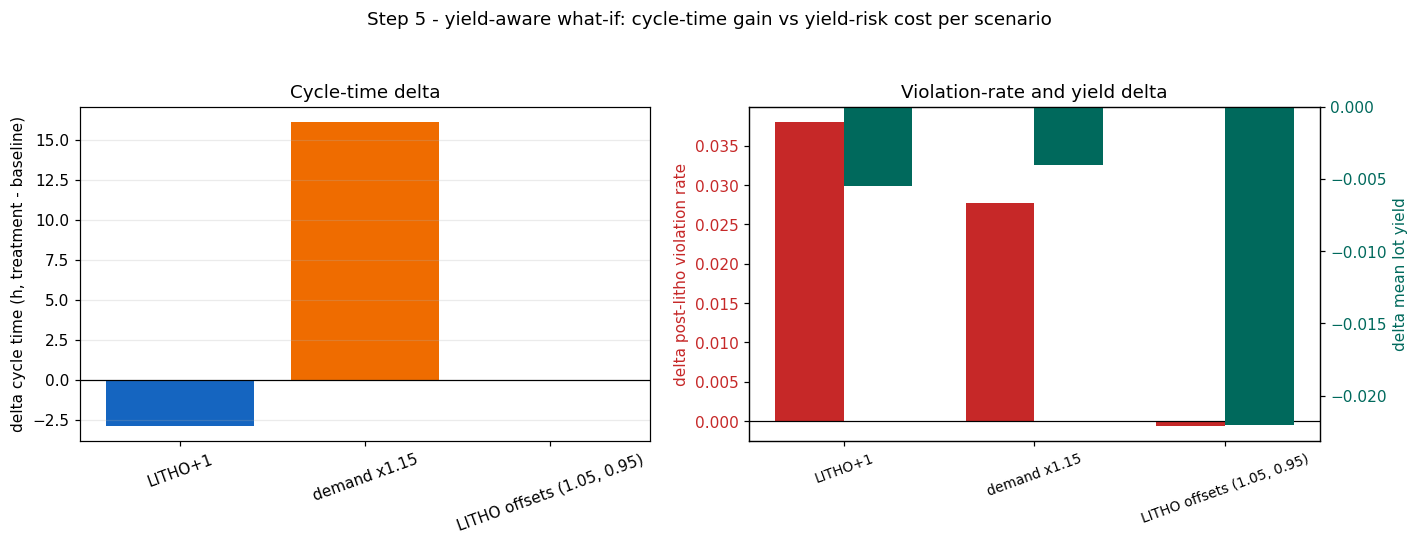

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
scenarios = whatif_summary["scenario"].tolist()
colors_s = ["#1565C0", "#EF6C00", "#6A1B9A"]

axes[0].bar(scenarios, whatif_summary["d_cycle_time"], color=colors_s)
axes[0].axhline(0, color="k", lw=0.8)
axes[0].set_ylabel("delta cycle time (h, treatment - baseline)")
axes[0].set_title("Cycle-time delta")
axes[0].tick_params(axis="x", rotation=20)
axes[0].grid(axis="y", alpha=0.25)

x = np.arange(len(scenarios))
width = 0.36
ax2 = axes[1]
bars_v = ax2.bar(x - width/2, whatif_summary["d_violation_rate"], width,
                  color="#C62828", label="delta violation rate")
ax2.set_ylabel("delta post-litho violation rate", color="#C62828")
ax2.tick_params(axis="y", labelcolor="#C62828")
ax2.axhline(0, color="k", lw=0.8)
ax3 = ax2.twinx()
bars_y = ax3.bar(x + width/2, whatif_summary["d_mean_lot_yield"], width,
                  color="#00695C", label="delta mean lot yield")
ax3.set_ylabel("delta mean lot yield", color="#00695C")
ax3.tick_params(axis="y", labelcolor="#00695C")
ax2.set_xticks(x); ax2.set_xticklabels(scenarios, rotation=20, fontsize=9)
ax2.set_title("Violation-rate and yield delta")
fig.suptitle("Step 5 - yield-aware what-if: cycle-time gain vs yield-risk cost per scenario", fontsize=12)
fig.tight_layout(rect=(0, 0, 1, 0.94))
fig.savefig(FIG / "m7_yield_whatif_tradeoff.png", bbox_inches="tight", dpi=150)
plt.show()


**Headline finding.** Adding a LITHO tool (LITHO+1) cuts cycle time by about
2.9 hours, the same direction as the M4/M6 capacity result, but it also
raises the post-litho queue-time violation rate and lowers mean lot yield:
a faster line moves lots through LITHO sooner, but that pushes more of them
into congested post-litho queues elsewhere, which is exactly the risk
channel `queue_time.py` is built to catch. The demand increase (+15%
arrivals) makes cycle time far worse (roughly +16 hours) and also raises
violations, the expected double penalty of an already-tight line taking on
more load. The chamber-offset scenario leaves cycle time nearly unchanged
but produces the largest yield loss and scrap-cost increase of the three,
because it is a pure quality effect with no capacity or demand change at
all. Put together: a capacity decision that looks purely positive on cycle
time can still be a net negative once the yield axis is added, so this kind
of decision needs both axes, not speed alone.


In [15]:
print("Headline what-if deltas (mean over 30 CRN-paired replications):")
display_cols = ["scenario", "d_cycle_time", "d_violation_rate", "d_mean_lot_yield", "d_scrap_cost"]
whatif_summary[display_cols].round(4)


Headline what-if deltas (mean over 30 CRN-paired replications):


,scenario,d_cycle_time,d_violation_rate,d_mean_lot_yield,d_scrap_cost
0,LITHO+1,-2.8702,0.0380,-0.0055,29820.0
1,demand x1.15,16.1321,0.0278,-0.0040,63960.0
2,"LITHO offsets (1.05, 0.95)",-0.0750,-0.0006,-0.0220,119980.0


## Summary

| Step | Output |
|---|---|
| 1 Queue-time windows | fixed window W = 0.4102 h (calibrated once at the 90th percentile of the baseline pooled gap distribution); baseline violation rate about 10% |
| 2 Ground-truth yield | transparent linear-additive p_latent, Binomial(25) realized defects; violating lots strictly riskier than clean lots, both in latent probability and realized defect rate |
| 3 Virtual metrology | leakage-safe time-split OLS on upstream-only features; high test R^2 because the ground truth is a simple known formula, not a claim about real-fab predictability; positive risk-ranking AUC |
| 4 Chamber matching | injected LITHO-1/LITHO-2 offset detected at alpha=0.01 on both processing duration and metrology reading; silent (false-positive guard) on the offset-free log |
| 5 Yield-aware what-if | LITHO+1 cuts cycle time but raises violations and lowers yield; +15% demand worsens both cycle time and violations; chamber offsets leave cycle time nearly flat but cost the most yield; CRN pairing verified exactly zero on baseline-vs-baseline |

**What M7 adds to the decision workflow.** Before this module, a capacity or
demand what-if (M4/M6) only reported cycle time, throughput, and cost. M7
adds a yield axis to the same CRN-paired comparisons, so a scenario that
looks purely beneficial on speed can now be checked for a hidden quality
cost, and a chamber-matching check can catch a run-to-run drift that would
otherwise look like ordinary process noise.

**Limits.** All yield coefficients (`QualityConfig`), the queue-time window
analogy, and the chamber-offset magnitudes are synthetic, hand-set values
chosen for this project, not measurements from a real fabrication line and
not a validated physical model of resist chemistry or chamber drift. The
high virtual-metrology R^2 is a property of the known, simple generative
truth used here, not evidence about real virtual-metrology performance. No
number in this notebook should be read as a forecast or a claim about any
real fab.

**Check scripts.** `py src/generator/validate_m2.py`,
`py src/generator/crn_check.py`, `py src/monitoring/monitoring_check.py`,
`py src/quality/quality_check.py`, `py src/quality/vm_check.py` all pass at
the time this notebook was executed.

**Figures (`reports/figures/`):** `m7_queue_time_window.png`,
`m7_lot_yield_distribution.png`, `m7_vm_pred_vs_actual.png`,
`m7_chamber_control_chart.png`, `m7_yield_whatif_tradeoff.png`.
